# Neural Network Image-to-Sentence Mapping

## Set-up and Loading the data

In [ ]:
! pip install num2words

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 11.7 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=af408ea8ec34aa67315cfc83421046b32ab242ea5e8964b04ca1cbd0f960079c
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [ ]:
import os
from tqdm import tqdm
import random
import re
from num2words import num2words

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import textwrap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import cv2

from collections import Counter

pd.options.display.max_rows = 500
pd.options.display.max_columns = 100

In [ ]:
BASE_DIR = "/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project"
DATA_DIR = os.path.join(BASE_DIR, 'Data')
datasets = os.listdir(DATA_DIR)

datasets = [dataset for dataset in datasets if 'csv' not in dataset]


# Checking if paths exist
for dataset in datasets:
  print(dataset,os.path.exists(os.path.join(DATA_DIR, dataset)))

Numbers_Data True
TicTacToe_Data True
Shapes_Data True


In [ ]:
print(torch.cuda.is_available())    # should print True
print(torch.cuda.get_device_name()) # should print Tesla T4

True
Tesla T4


## Reading the data
- Creating dataframe for each of the datasets
- Getting the file_name and the text.
- Making it easer to process the text.

In [ ]:
raw_data = {}
data_splits = ["train","test","val"]
for dataset in datasets:
  dataset_path = os.path.join(DATA_DIR, dataset)
  main_df = pd.DataFrame(columns=["file_name","file_path","text","split","dataset"])
  for split in data_splits:
    split_path = os.path.join(dataset_path, split)
    file_names = os.listdir(os.path.join(split_path,"images"))
    file_paths = [os.path.join(split_path,"images",file_name) for file_name in file_names]
    text = []
    for sample in tqdm(file_names):
      text_file_name = sample.split(".")[0]+".txt"
      with open(os.path.join(split_path,"text",text_file_name)) as f:
        text.append(f.read())
    split_type = len(text)*[split]
    dataset_type = len(text)*[dataset]
    df = pd.DataFrame({"file_name":file_names,"file_path":file_paths,"text":text,"split":split_type,"dataset":dataset_type})
    main_df = pd.concat([main_df,df],ignore_index=True)
  raw_data[dataset] = main_df
  print(f"Dataframe for {dataset} created")


file_names = []
file_paths = []
text = []
df = {}
main_df = {}

100%|██████████| 744/744 [00:02<00:00, 251.85it/s]


Dataframe for Numbers_Data created


100%|██████████| 750/750 [00:02<00:00, 273.65it/s]


Dataframe for TicTacToe_Data created


100%|██████████| 744/744 [00:02<00:00, 256.84it/s]

Dataframe for Shapes_Data created


In [ ]:
# Saving dataframe for future use.
for dataset in datasets:
  raw_data[dataset].to_csv(os.path.join(DATA_DIR,dataset+".csv"))

## Data Preprocessing

### Preprocessing Steps

| Step | Action | Example | Reason |
| :--- | :--- | :--- | :--- |
| **Player names** | Replace with `PLAYER_X` and `PLAYER_O` | Liam is X $\rightarrow$ `PLAYER_X` | Names inflate vocabulary; cannot be learned from image. |
| **Semicolons** | Replace with full stop and space | `...corner; PLAYER_O...` $\rightarrow$ `...corner. PLAYER_O...` | Keeps structure without rare punctuation tokens. |
| **Size words** | Normalise to *large, medium, small* | `sizeable`, `big` $\rightarrow$ `large` | Reduces vocabulary; cleaner mapping. |
| **Casing** | Lowercase everything | `Also visible` $\rightarrow$ `also visible` | Avoids duplicate tokens for the same word. |
| **Hyphens** | Keep in position words | `top-left`, `bottom-right` | Preserves positional meaning as a single token. |
| **Filler phrases** | Keep as-is | `also visible`, `there is` | Removing them breaks grammatical correctness. |
| **Commas** | Keep as-is | `a big circle, with...` | Carry structural meaning. |
| **Quotes/Brackets** | Remove | `"a big circle"` $\rightarrow$ `a big circle` | No semantic value. |
| **Numbers** | Convert to words | `63` $\rightarrow$ `sixty three` | Model learns digit names, not opaque tokens. |



### Reading the CSV files


In [ ]:
raw_data = {}
for dataset in datasets:
  raw_data[dataset] = pd.read_csv(os.path.join(DATA_DIR,dataset+".csv"),index_col=0)

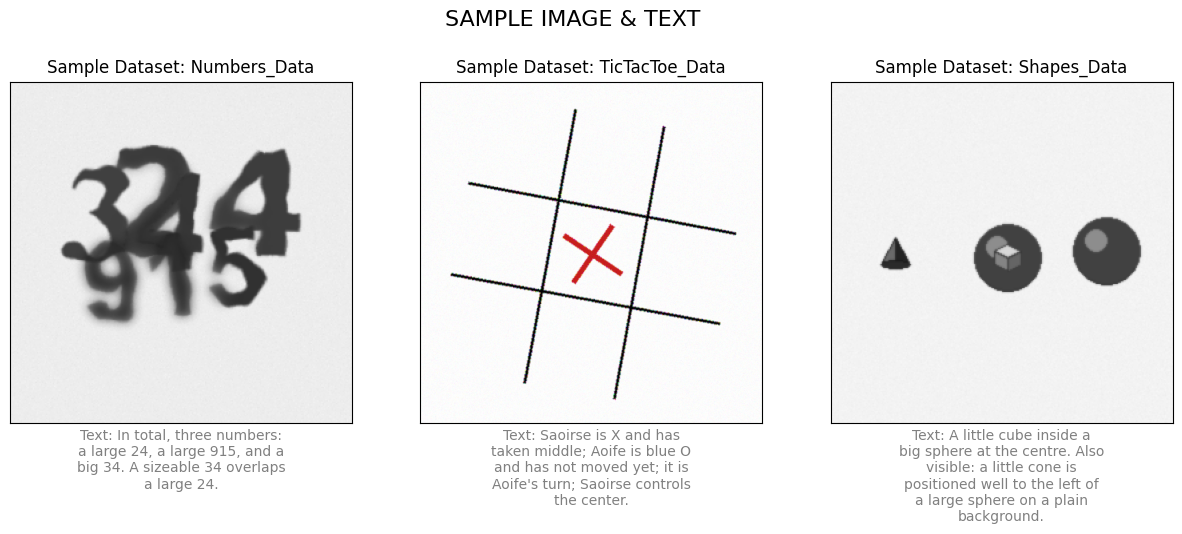

In [ ]:
plt.figure(figsize=(15, 5))
plt.suptitle('SAMPLE IMAGE & TEXT', fontsize=16)

for i in range(len(datasets)):
    plt.subplot(1, 3, i + 1)

    random_sample_index = random.randint(0, len(raw_data[datasets[i]]) - 1)
    img_path = raw_data[datasets[i]].iloc[random_sample_index, 1]

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    raw_text = f"Text: {raw_data[datasets[i]].iloc[random_sample_index, 2]}"
    wrapped_text = "\n".join(textwrap.wrap(raw_text, width=30))

    plt.imshow(img_rgb)
    plt.title(f"Sample Dataset: {datasets[i]}", fontsize=12)
    plt.xlabel(wrapped_text, fontsize=10, color='gray')

    plt.xticks([])
    plt.yticks([])

plt.show()


### Player Names

In [ ]:
df = raw_data["TicTacToe_Data"].copy(deep=True)

In [ ]:
df.head()

,file_name,file_path,text,split,dataset
0,test_3550.png,/content/drive/Othercomputers/My Laptop/Deskto...,Liam is X and has taken up and left from cente...,train,TicTacToe_Data
1,test_3552.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Aoife is red X and has taken middle, above the...",train,TicTacToe_Data
2,test_3551.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Liam is X and has taken left of centre, top le...",train,TicTacToe_Data
3,test_3553.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Liam is X and has taken middle row left, up an...",train,TicTacToe_Data
4,test_3555.png,/content/drive/Othercomputers/My Laptop/Deskto...,"Siobhán is X and has taken top left corner, do...",train,TicTacToe_Data


In [ ]:
df.shape

(5000, 5)

In [ ]:
# First word of ever sentence is a Name, So lets get all the names present in the data
names = set([text.split(' ')[0] for text in df['text']])
names

{'Aoife', 'Eoin', 'Liam', 'Niamh', 'Saoirse', 'Seán', 'Siobhán'}

In [ ]:
def replace_player_names(text):
    # 1. Identify who is X and who is O
    name_x_match = re.search(r'([A-Z][a-z]\w+) is\s*(?:red)?\s*X(?:\s+and)', text)
    name_o_match = re.search(r'([A-Z][a-z]\w+) is\s*(?:blue)?\s*O(?:\s+and)', text)
    # print(name_x_match)
    # print(name_o_match)
    if not name_x_match or not name_o_match:
        return text

    name_x = name_x_match.group(1)
    name_o = name_o_match.group(1)

    pattern_x = rf'\b{name_x}(\'s)?\b'
    pattern_o = rf'\b{name_o}(\'s)?\b'

    text = re.sub(rf'{name_x} is\s*(?:red)?\s*X(?:\s+and)', 'PLAYER_X', text)
    text = re.sub(rf'{name_o} is\s*(?:blue)?\s*O(?:\s+and)', 'PLAYER_O', text)


    text = re.sub(pattern_x, lambda m: "PLAYER_X" + (m.group(1) if m.group(1) else ""), text)
    text = re.sub(pattern_o, lambda m: "PLAYER_O" + (m.group(1) if m.group(1) else ""), text)

    text = text.replace("PLAYER_X is X", "PLAYER_X")
    text = text.replace("PLAYER_O is O", "PLAYER_O")

    text = re.sub(r'\bred\s+X\s+(?:and\s+)?(\w+)', r'PLAYER_X \1', text)
    text = re.sub(r'\bblue\s+O\s+(?:and\s+)?(\w+)', r'PLAYER_O \1', text)

    text = text.replace("  ", " ").strip()

    return text

In [ ]:
print("Original ------> " + df['text'].iloc[2])
replace_player_names(df['text'].iloc[2])

Original ------> Liam is X and has taken left of centre, top left corner, middle row right and below the center; Seán is O and has gone for bottom left corner, above the center and center; it is Seán's turn; Seán controls the center.



"PLAYER_X has taken left of centre, top left corner, middle row right and below the center; PLAYER_O has gone for bottom left corner, above the center and center; it is PLAYER_O's turn; PLAYER_O controls the center."

In [ ]:
testing_text = df['text'].apply(replace_player_names)

In [ ]:
testing_text

,text
0,"PLAYER_X has taken up and left from center, ri..."
1,"PLAYER_X has taken middle, above the center, d..."
2,"PLAYER_X has taken left of centre, top left co..."
3,"PLAYER_X has taken middle row left, up and lef..."
4,"PLAYER_X has taken top left corner, down and l..."
...,...
4995,"PLAYER_X has gone for above the center, up and..."
4996,"PLAYER_X has taken bottom right corner, top le..."
4997,"PLAYER_X has taken center, middle row right, b..."
4998,"PLAYER_X has taken up and right from center, u..."


In [ ]:
# checking if any of the names are still present
for i in names:
  for text in testing_text:
    if i in text:
      print(i)

In [ ]:
df['text'] = testing_text

In [ ]:
processed_data = {}
processed_data['TicTacToe_Data'] = df

### Semicolons

In [ ]:
df = processed_data["TicTacToe_Data"].copy(deep=True)

In [ ]:
df.head()

,file_name,file_path,text,split,dataset
0,test_3550.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken up and left from center, ri...",train,TicTacToe_Data
1,test_3552.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken middle, above the center, d...",train,TicTacToe_Data
2,test_3551.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken left of centre, top left co...",train,TicTacToe_Data
3,test_3553.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken middle row left, up and lef...",train,TicTacToe_Data
4,test_3555.png,/content/drive/Othercomputers/My Laptop/Deskto...,"PLAYER_X has taken top left corner, down and l...",train,TicTacToe_Data


In [ ]:
df['text'] = df['text'].apply(lambda x: x.replace(";","."))

In [ ]:
processed_data["TicTacToe_Data"] = df

### Lower Case, Removing Q&A and Normalising Size words

In [ ]:
master_data = pd.DataFrame()
for dataset in datasets:
  if dataset in processed_data:
    df = processed_data[dataset]
  else:
    df = raw_data[dataset]
  master_data = pd.concat([master_data,df],ignore_index=True)

In [ ]:
master_data.shape

(15000, 5)

In [ ]:
# Converting all the text to lower case.
master_data['text'] = master_data['text'].apply(lambda x: x.lower())
master_data['text'] = master_data['text'].apply(lambda x: x.strip())
master_data['text'] = master_data['text'].apply(lambda x: x.replace(";","."))

In [ ]:
def convert_question_to_sentence(text):
  test_text = text
  # print(text)
  # text = text.replace("also visible:","")
  question = re.search(r'(also visible:|where is the)(.+?\?)',text).group()
  # print(str(question))
  # print(question.group(2))
  object_ = re.search(r'(?:where is the) (.+?)\?',str(question)).group(1)
  # print(object_)
  text = text.replace(str(question),"")
  text = text.replace(" it is","the "+object_+" is")
  # print(text)
  return text


def normalise_size_words(text):
  text = text.replace("big","large")
  text = text.replace("sizeable","large")
  text = text.replace("little","small")
  text = text.replace("tiny","small")
  text = text.replace("medium-sized","medium")
  text = text.replace("mid-sized","medium")
  return text

In [ ]:
master_data['text'] = master_data['text'].apply(lambda x: convert_question_to_sentence(x) if '?' in x else x)
master_data['text'] = master_data['text'].apply(lambda x: normalise_size_words(x))

### Numbers-to-words

In [ ]:
def number_to_words(text):
    numbers = sorted(re.findall(r'\d+', text), key=len, reverse=True)
    for number in numbers:
        num_words = num2words(int(number))
        num_words = num_words.replace(",", "")
        num_words = num_words.replace("-", " ")
        text = re.sub(r'\b' + number + r'\b', num_words, text)
    return text

In [ ]:
master_data['text'] = master_data['text'].apply(lambda x: number_to_words(x))

In [ ]:
master_data.to_csv(os.path.join(DATA_DIR,"master_data.csv"))

## Tokeniser

### Special Tokens

| Token | Purpose |
| :--- | :--- |
| `<PAD>` | Pads all sentences in a batch to the same length. |
| `<START>` | Signals the decoder to begin generating. |
| `<END>` | Signals the decoder to stop generating. |
| `<UNK>` | Replaces any token not seen during training. |

### Sequence Settings
*   **Max token length:** 50 tokens (including `START` and `END`).
*   **Tokenisation:** Split on whitespace and punctuation.
*   **Vocabulary:** Built from all three training datasets combined.

### Checking data

In [ ]:
master_data = pd.read_csv("/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data/master_data.csv")

In [ ]:
master_data.shape

(15000, 6)

In [ ]:
master_data.head()

,Unnamed: 0,file_name,file_path,text,split,dataset
0,0,sample_003565.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, three numbers: a large ninety one, a...",train,Numbers_Data
1,1,sample_003571.png,/content/drive/Othercomputers/My Laptop/Deskto...,four numbers are visible: a medium seven hundr...,train,Numbers_Data
2,2,sample_003570.png,/content/drive/Othercomputers/My Laptop/Deskto...,three numbers appear in the scene: a medium ei...,train,Numbers_Data
3,3,sample_003569.png,/content/drive/Othercomputers/My Laptop/Deskto...,"the scene contains a medium three, a large fou...",train,Numbers_Data
4,4,sample_003572.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, four numbers: a small forty two, a s...",train,Numbers_Data


In [ ]:
master_data[['dataset','split']].value_counts()

dataset         split
Numbers_Data    train    3512
Shapes_Data     train    3512
TicTacToe_Data  train    3500
                val       750
                test      750
Numbers_Data    test      744
                val       744
Shapes_Data     test      744
                val       744
Name: count, dtype: int64

In [ ]:
print(master_data.head())
print(master_data.columns)
print(master_data.shape)

   Unnamed: 0          file_name  \
0           0  sample_003565.png   
1           1  sample_003571.png   
2           2  sample_003570.png   
3           3  sample_003569.png   
4           4  sample_003572.png   

                                           file_path  \
0  /content/drive/Othercomputers/My Laptop/Deskto...   
1  /content/drive/Othercomputers/My Laptop/Deskto...   
2  /content/drive/Othercomputers/My Laptop/Deskto...   
3  /content/drive/Othercomputers/My Laptop/Deskto...   
4  /content/drive/Othercomputers/My Laptop/Deskto...   

                                                text  split       dataset  
0  in total, three numbers: a large ninety one, a...  train  Numbers_Data  
1  four numbers are visible: a medium seven hundr...  train  Numbers_Data  
2  three numbers appear in the scene: a medium ei...  train  Numbers_Data  
3  the scene contains a medium three, a large fou...  train  Numbers_Data  
4  in total, four numbers: a small forty two, a s...  train  Numbe

### Tokenisation

In [ ]:
def tokenise(text):
    tokens = re.findall(r'\b\w+(?:-\w+)*\b|[.,!?]', text)
    return tokens

In [ ]:
train_data = master_data[master_data['split'] == 'train'].copy(deep=True)
val_data   = master_data[master_data['split'] == 'val'].copy(deep=True)
test_data  = master_data[master_data['split'] == 'test'].copy(deep=True)

In [ ]:
train_data['tokens'] = train_data['text'].apply(tokenise)
val_data['tokens']   = val_data['text'].apply(tokenise)
test_data['tokens']  = test_data['text'].apply(tokenise)

In [ ]:
train_data[train_data['text'].str.contains('-')]['text'].iloc[0]

'a small five thousand two hundred and fifty three, with five in orange, two in yellow, five in green and three in purple at the middle-left and a large orange nine at the middle-right appear in the scene.'

In [ ]:
sample = train_data[train_data['text'].str.contains('-')]['text'].iloc[0]
print(tokenise(sample))

['a', 'small', 'five', 'thousand', 'two', 'hundred', 'and', 'fifty', 'three', ',', 'with', 'five', 'in', 'orange', ',', 'two', 'in', 'yellow', ',', 'five', 'in', 'green', 'and', 'three', 'in', 'purple', 'at', 'the', 'middle-left', 'and', 'a', 'large', 'orange', 'nine', 'at', 'the', 'middle-right', 'appear', 'in', 'the', 'scene', '.']


### Building the vocabulary

In [ ]:
# Only from the training data
all_tokens = [token for tokens in train_data['tokens'] for token in tokens]

In [ ]:
token_counts = Counter(all_tokens)

In [ ]:
print(f"Total unique tokens: {len(token_counts)}")
print(token_counts.most_common(10))

Total unique tokens: 168
[('and', 22495), (',', 22452), ('.', 22419), ('a', 22200), ('in', 13202), ('the', 12563), ('has', 8627), ('small', 8309), ('large', 8280), ('center', 7200)]


In [ ]:
special_tokens = ['<PAD>', '<START>', '<END>', '<UNK>']
vocab = special_tokens + [token for token, count in token_counts.items()]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}

In [ ]:
print(f"Vocabulary size: {len(word2idx)}")
print(f"PAD index: {word2idx['<PAD>']}")
print(f"START index: {word2idx['<START>']}")
print(f"END index: {word2idx['<END>']}")
print(f"UNK index: {word2idx['<UNK>']}")

# test a real word
print(f"'the' index: {word2idx['the']}")
print(f"idx2word[0]: {idx2word[0]}")

Vocabulary size: 172
PAD index: 0
START index: 1
END index: 2
UNK index: 3
'the' index: 31
idx2word[0]: <PAD>


### Encoding

In [ ]:
def encode(tokens):
    # add start and end, convert to integers
    tokens = ['<START>']+tokens+['<END>']
    tokens = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
    return tokens

In [ ]:
sample_tokens = train_data['tokens'].iloc[0]
encoded = encode(sample_tokens)
print(encoded)
print(f"Length: {len(encoded)}")

# verify start and end
print(f"First token: {encoded[0]}")   # should be 1 (<START>)
print(f"Last token: {encoded[-1]}")   # should be 2 (<END>)

[1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 6, 9, 13, 14, 15, 16, 17, 6, 16, 9, 13, 18, 19, 20, 15, 16, 21, 22, 23, 9, 10, 11, 12, 24, 9, 13, 14, 15, 16, 17, 23, 2]
Length: 42
First token: 1
Last token: 2


In [ ]:
train_data['encoded'] = train_data['tokens'].apply(encode)
val_data['encoded']   = val_data['tokens'].apply(encode)
test_data['encoded']  = test_data['tokens'].apply(encode)

### Padding to 150 tokens

In [ ]:
def pad(encoded, max_length=150):
    # pad or truncate to max_length
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
    else:
        encoded = encoded + [word2idx['<PAD>']] * (max_length - len(encoded))
    return encoded

In [ ]:
# test padding (short sequence)
short = encode(['player_x', 'has', 'won', '.'])
padded = pad(short)
print(f"Length: {len(padded)}")
print(f"Last few tokens: {padded[-5:]}")  # should end with 0s

# test truncation (long sequence)
long = encode(['word'] * 200)
truncated = pad(long)
print(f"Truncated length: {len(truncated)}")  # should be 150

Length: 150
Last few tokens: [0, 0, 0, 0, 0]
Truncated length: 150


In [ ]:
train_data['padded'] = train_data['encoded'].apply(pad)
val_data['padded']   = val_data['encoded'].apply(pad)
test_data['padded']  = test_data['encoded'].apply(pad)

In [ ]:
# every sequence should be exactly 150
assert all(len(x) == 150 for x in train_data['padded'])
assert all(len(x) == 150 for x in val_data['padded'])
assert all(len(x) == 150 for x in test_data['padded'])
print("All sequences are length 150 ✅")

All sequences are length 150 ✅


### Checking Coverage on Val and Test set

In [ ]:
def count_unknowns(encoded_series):
    unk_idx = word2idx['<UNK>']
    total_tokens = sum(len(seq) for seq in encoded_series)
    unk_count = sum(seq.count(unk_idx) for seq in encoded_series)
    return unk_count / total_tokens * 100

print(f"Val UNK%:  {count_unknowns(val_data['encoded']):.2f}%")
print(f"Test UNK%: {count_unknowns(test_data['encoded']):.2f}%")

Val UNK%:  0.00%
Test UNK%: 0.00%


## Data Loader

In [ ]:
class ImageCaptionDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),           # converts to tensor and scales 0-255 to 0-1
        ])

    def __len__(self):
        # return number of samples
        return len(self.data)
        ...

    def __getitem__(self, idx):
        # 1. get file path and load image
        # 2. convert L to RGB if needed
        # 3. apply transforms
        # 4. get the padded encoded sequence
        # 5. return image tensor and sequence tensor
        file_path = self.data.iloc[idx]['file_path']
        image = Image.open(file_path).convert('RGB')
        image_tensor = self.transform(image)
        sequence_tensor = torch.tensor(self.data.iloc[idx]['padded'])
        return image_tensor, sequence_tensor

In [ ]:
train_dataset = ImageCaptionDataset(train_data)
val_dataset   = ImageCaptionDataset(val_data)
test_dataset  = ImageCaptionDataset(test_data)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [ ]:
images, sequences = next(iter(train_loader))
print(f"Image batch shape:    {images.shape}")
print(f"Sequence batch shape: {sequences.shape}")

Image batch shape:    torch.Size([64, 3, 128, 128])
Sequence batch shape: torch.Size([64, 150])


## Transformer Decoder

transformer_decoder_architecture.svg

In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256,max_length=150,num_heads=8,N_layers=3,ff_dim=512,dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embed_dim = embed_dim
        self.pos_embedding = nn.Embedding(max_length, embed_dim)
        decoder_layer = nn.TransformerDecoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=N_layers)
        self.fc_out = nn.Linear(embed_dim, vocab_size)
    def forward(self, tgt, memory):
        # tgt    = token sequence [batch, seq_len]
        # memory = CNN feature map [batch, num_patches, embed_dim]
        seq_len = tgt.shape[1]
        positions = torch.arange(seq_len, device=tgt.device)
        token_emb = self.embedding(tgt)
        pos_emb   = self.pos_embedding(positions)
        x = token_emb + pos_emb
        mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=tgt.device)
        x = self.transformer(x, memory, tgt_mask=mask)
        x = self.fc_out(x)
        return x

In [ ]:
# create decoder
decoder = TransformerDecoder(vocab_size=172)

# dummy inputs
batch_size = 2
seq_len    = 10
num_patches = 64  # 8x8 CNN feature map flattened
embed_dim  = 256

tgt    = torch.randint(0, 172, (batch_size, seq_len))         # fake token sequences
memory = torch.randn(batch_size, num_patches, embed_dim)      # fake CNN features

# forward pass
output = decoder(tgt, memory)
print(f"Input shape:  {tgt.shape}")
print(f"Memory shape: {memory.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([2, 10])
Memory shape: torch.Size([2, 64, 256])
Output shape: torch.Size([2, 10, 172])


## Approach A — Shallow CNN

In [ ]:
class ShallowCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, padding=1)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)


    def forward(self, x):
        # pass through conv layers
        conv1 = F.max_pool2d(F.relu(self.conv1(x)),2)
        conv2 = F.max_pool2d(F.relu(self.conv2(conv1)),2)
        conv2 = self.proj(conv2)
        # flatten spatial dims
        x = conv2.flatten(2)
        # permute to [batch, num_patches, embed_dim]
        x = x.permute(0, 2, 1)
        return x

In [ ]:
cnn = ShallowCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn(x)
print(out.shape)

torch.Size([2, 1024, 256])


In [ ]:
# create both models
cnn     = ShallowCNN()
decoder = TransformerDecoder(vocab_size=172)

# dummy inputs
images = torch.randn(2, 3, 128, 128)
tokens = torch.randint(0, 172, (2, 10))

# forward pass through both
memory = cnn(images)
output = decoder(tokens, memory)

print(f"CNN output shape:     {memory.shape}")
print(f"Decoder output shape: {output.shape}")

CNN output shape:     torch.Size([2, 1024, 256])
Decoder output shape: torch.Size([2, 10, 172])


## Approach B — Deep CNN

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        # 5 conv layers + projection
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)
    def forward(self, x):
        # pass through conv layers with relu and selective pooling
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x,2)
        x = F.relu(self.conv5(x))
        x = self.proj(x)
        # flatten and permute
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        return x

In [ ]:
cnn_deep = DeepCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn_deep(x)
print(out.shape)  # should be [2, 1024, 256]

torch.Size([2, 1024, 256])


## Approach C — ResNet-style CNN

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x
        out = F.relu(self.conv1(x))
        out = self.conv2(out)
        out = F.relu(out + residual)
        return out

class ResNetCNN(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.res1 = ResidualBlock(64)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, padding=1)
        self.res2 = ResidualBlock(256)
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.res1(out)
        out = F.max_pool2d(out,2)
        out = self.conv2(out)
        out = self.res2(out)
        out = F.max_pool2d(out, 2)
        out = self.proj(out)
        out = out.flatten(2)
        out = out.permute(0, 2, 1)
        return out

In [ ]:
cnn_res = ResNetCNN()
x = torch.randn(2, 3, 128, 128)
out = cnn_res(x)
print(out.shape)

torch.Size([2, 1024, 256])


## Training

### Training Loop

In [ ]:
def train_epoch(cnn, decoder, train_loader, optimizer, criterion, device):
  cnn.train()
  decoder.train()
  total_loss = 0

  for images, sequences in tqdm(train_loader, desc='Training', leave=False):
    # 1. move to device
    X, y = images.to(device), sequences.to(device)
    # 2. split into input and target sequences
    input_seq  = y[:, :-1]   # all but last token
    target_seq = y[:, 1:]    # all but first token
    # 3. forward pass through CNN
    pred_seq = cnn(X)
    optimizer.zero_grad()
    # 4. forward pass through decoder
    output = decoder(input_seq, pred_seq)
    # 5. calculate loss
    loss = criterion(output.reshape(-1, output.shape[-1]), target_seq.reshape(-1))
    # 6. backpropagate
    loss.backward()
    optimizer.step()
    # 7. update weights
    total_loss += loss.item()

  return total_loss / len(train_loader)

In [ ]:
def val_epoch(cnn, decoder, val_loader, criterion, device):
    cnn.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for images, sequences in val_loader:
            # same steps as train_epoch
            # but no optimizer.zero_grad(), loss.backward(), optimizer.step()
            X, y = images.to(device), sequences.to(device)
            input_seq  = y[:, :-1]
            target_seq = y[:, 1:]
            pred_seq = cnn(X)
            output = decoder(input_seq, pred_seq)
            loss = criterion(output.reshape(-1, output.shape[-1]), target_seq.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [ ]:
def train(cnn, decoder, train_loader, val_loader, optimizer, criterion, device, num_epochs=50, patience=5,save_path="/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/best_model.pt"):
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss':[],'val_loss':[],'lr':[]}

    for epoch in range(num_epochs):
        # train and validate
        train_loss = train_epoch(cnn, decoder, train_loader, optimizer, criterion, device)
        val_loss   = val_epoch(cnn, decoder, val_loader, criterion, device)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        scheduler.step()

        # early stopping and checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # save best model
            torch.save({
                'cnn': cnn.state_dict(),
                'decoder': decoder.state_dict(),
            }, save_path)
            print(f"  Model saved ✅")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    return history

### Testing on small dataset

In [ ]:
train_numbers = train_data[train_data['dataset']=='Numbers_Data'].head(34)
train_shapes  = train_data[train_data['dataset']=='Shapes_Data'].head(33)
train_xo      = train_data[train_data['dataset']=='TicTacToe_Data'].head(33)
balanced_dataset = pd.concat([train_numbers, train_shapes, train_xo]).reset_index(drop=True)

# small_dataset = torch.utils.data.Subset(train_dataset, range(100))
small_dataset = ImageCaptionDataset(balanced_dataset)
small_loader  = DataLoader(small_dataset, batch_size=16, shuffle=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 100

cnn     = ShallowCNN().to(device)
decoder = TransformerDecoder(vocab_size=172).to(device)

optimizer = torch.optim.Adam(
    list(cnn.parameters()) + list(decoder.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=int(num_epochs/5),    # number of epochs
    eta_min=1e-5 # minimum learning rate
)
criterion = nn.CrossEntropyLoss(ignore_index=0)

history = train(cnn, decoder, small_loader, val_loader, optimizer, criterion, device,num_epochs=num_epochs,patience=100)

Epoch 1/100 | Train Loss: 4.1318 | Val Loss: 3.7732
  Model saved ✅


Epoch 2/100 | Train Loss: 2.7320 | Val Loss: 3.3392
  Model saved ✅


Epoch 3/100 | Train Loss: 2.0134 | Val Loss: 3.1579
  Model saved ✅


Epoch 4/100 | Train Loss: 1.5619 | Val Loss: 3.0957
  Model saved ✅


Epoch 5/100 | Train Loss: 1.2891 | Val Loss: 3.1021


Epoch 6/100 | Train Loss: 1.1053 | Val Loss: 3.2114


Epoch 7/100 | Train Loss: 0.9786 | Val Loss: 3.2516


Epoch 8/100 | Train Loss: 0.8969 | Val Loss: 3.3223


Epoch 9/100 | Train Loss: 0.8211 | Val Loss: 3.3591


Epoch 10/100 | Train Loss: 0.7431 | Val Loss: 3.3522


Epoch 11/100 | Train Loss: 0.6987 | Val Loss: 3.4776


Epoch 12/100 | Train Loss: 0.6553 | Val Loss: 3.3745


Epoch 13/100 | Train Loss: 0.6254 | Val Loss: 3.4821


Epoch 14/100 | Train Loss: 0.5959 | Val Loss: 3.4863


Epoch 15/100 | Train Loss: 0.5742 | Val Loss: 3.4684


Epoch 16/100 | Train Loss: 0.5625 | Val Loss: 3.4902


Epoch 17/100 | Train Loss: 0.5417 | Val Loss: 3.5059


Epoch 18/100 | Train Loss: 0.5336 | Val Loss: 3.5043


Epoch 19/100 | Train Loss: 0.5158 | Val Loss: 3.5028


Epoch 20/100 | Train Loss: 0.5122 | Val Loss: 3.5044


Epoch 21/100 | Train Loss: 0.5128 | Val Loss: 3.5050


Epoch 22/100 | Train Loss: 0.5163 | Val Loss: 3.5064


Epoch 23/100 | Train Loss: 0.5153 | Val Loss: 3.5094


Epoch 24/100 | Train Loss: 0.5072 | Val Loss: 3.5130


Epoch 25/100 | Train Loss: 0.4927 | Val Loss: 3.5176


Epoch 26/100 | Train Loss: 0.5010 | Val Loss: 3.5413


Epoch 27/100 | Train Loss: 0.4849 | Val Loss: 3.5505


Epoch 28/100 | Train Loss: 0.4764 | Val Loss: 3.5579


Epoch 29/100 | Train Loss: 0.4380 | Val Loss: 3.5884


Epoch 30/100 | Train Loss: 0.4183 | Val Loss: 3.6221


Epoch 31/100 | Train Loss: 0.4093 | Val Loss: 3.6820


Epoch 32/100 | Train Loss: 0.3752 | Val Loss: 3.6968


Epoch 33/100 | Train Loss: 0.3687 | Val Loss: 3.7530


Epoch 34/100 | Train Loss: 0.3551 | Val Loss: 3.8127


Epoch 35/100 | Train Loss: 0.3415 | Val Loss: 3.8888


Epoch 36/100 | Train Loss: 0.3153 | Val Loss: 3.9228


Epoch 37/100 | Train Loss: 0.2942 | Val Loss: 3.9564


Epoch 38/100 | Train Loss: 0.2824 | Val Loss: 3.9498


Epoch 39/100 | Train Loss: 0.2744 | Val Loss: 4.0751


Epoch 40/100 | Train Loss: 0.2744 | Val Loss: 4.0717


Epoch 41/100 | Train Loss: 0.2769 | Val Loss: 4.1356


Epoch 42/100 | Train Loss: 0.2560 | Val Loss: 4.1143


Epoch 43/100 | Train Loss: 0.2432 | Val Loss: 4.2549


Epoch 44/100 | Train Loss: 0.2309 | Val Loss: 4.1762


Epoch 45/100 | Train Loss: 0.2157 | Val Loss: 4.2992


Epoch 46/100 | Train Loss: 0.2138 | Val Loss: 4.2059


Epoch 47/100 | Train Loss: 0.1948 | Val Loss: 4.2507


Epoch 48/100 | Train Loss: 0.1909 | Val Loss: 4.3094


Epoch 49/100 | Train Loss: 0.1910 | Val Loss: 4.2727


Epoch 50/100 | Train Loss: 0.1671 | Val Loss: 4.3444


Epoch 51/100 | Train Loss: 0.1633 | Val Loss: 4.3738


Epoch 52/100 | Train Loss: 0.1591 | Val Loss: 4.3543


Epoch 53/100 | Train Loss: 0.1521 | Val Loss: 4.4014


Epoch 54/100 | Train Loss: 0.1409 | Val Loss: 4.4073


Epoch 55/100 | Train Loss: 0.1400 | Val Loss: 4.4154


Epoch 56/100 | Train Loss: 0.1320 | Val Loss: 4.4196


Epoch 57/100 | Train Loss: 0.1295 | Val Loss: 4.4149


Epoch 58/100 | Train Loss: 0.1330 | Val Loss: 4.4168


Epoch 59/100 | Train Loss: 0.1216 | Val Loss: 4.4180


Epoch 60/100 | Train Loss: 0.1288 | Val Loss: 4.4181


Epoch 61/100 | Train Loss: 0.1230 | Val Loss: 4.4182


Epoch 62/100 | Train Loss: 0.1248 | Val Loss: 4.4188


Epoch 63/100 | Train Loss: 0.1246 | Val Loss: 4.4221


Epoch 64/100 | Train Loss: 0.1251 | Val Loss: 4.4277


Epoch 65/100 | Train Loss: 0.1298 | Val Loss: 4.4304


Epoch 66/100 | Train Loss: 0.1210 | Val Loss: 4.4392


Epoch 67/100 | Train Loss: 0.1235 | Val Loss: 4.4403


Epoch 68/100 | Train Loss: 0.1228 | Val Loss: 4.4418


Epoch 69/100 | Train Loss: 0.1204 | Val Loss: 4.4778


Epoch 70/100 | Train Loss: 0.1268 | Val Loss: 4.4930


Epoch 71/100 | Train Loss: 0.1288 | Val Loss: 4.4814


Epoch 72/100 | Train Loss: 0.1348 | Val Loss: 4.4862


Epoch 73/100 | Train Loss: 0.1338 | Val Loss: 4.4792


Epoch 74/100 | Train Loss: 0.1328 | Val Loss: 4.5442


Epoch 75/100 | Train Loss: 0.1466 | Val Loss: 4.5935


Epoch 76/100 | Train Loss: 0.1388 | Val Loss: 4.5003


Epoch 77/100 | Train Loss: 0.1479 | Val Loss: 4.5199


Epoch 78/100 | Train Loss: 0.1511 | Val Loss: 4.5707


Epoch 79/100 | Train Loss: 0.1485 | Val Loss: 4.5286


Epoch 80/100 | Train Loss: 0.1340 | Val Loss: 4.5417


Epoch 81/100 | Train Loss: 0.1386 | Val Loss: 4.5800


Epoch 82/100 | Train Loss: 0.1395 | Val Loss: 4.6291


Epoch 83/100 | Train Loss: 0.1365 | Val Loss: 4.6334


Epoch 84/100 | Train Loss: 0.1425 | Val Loss: 4.6788


Epoch 85/100 | Train Loss: 0.1376 | Val Loss: 4.6291


Epoch 86/100 | Train Loss: 0.1396 | Val Loss: 4.6244


Epoch 87/100 | Train Loss: 0.1324 | Val Loss: 4.6424


Epoch 88/100 | Train Loss: 0.1185 | Val Loss: 4.6518


Epoch 89/100 | Train Loss: 0.1228 | Val Loss: 4.7018


Epoch 90/100 | Train Loss: 0.1142 | Val Loss: 4.7357


Epoch 91/100 | Train Loss: 0.1163 | Val Loss: 4.7177


Epoch 92/100 | Train Loss: 0.1120 | Val Loss: 4.7434


Epoch 93/100 | Train Loss: 0.1087 | Val Loss: 4.7613


Epoch 94/100 | Train Loss: 0.1058 | Val Loss: 4.7657


Epoch 95/100 | Train Loss: 0.1024 | Val Loss: 4.7666


Epoch 96/100 | Train Loss: 0.0981 | Val Loss: 4.7651


Epoch 97/100 | Train Loss: 0.0957 | Val Loss: 4.7749


Epoch 98/100 | Train Loss: 0.0996 | Val Loss: 4.7761


Epoch 99/100 | Train Loss: 0.1016 | Val Loss: 4.7767


Epoch 100/100 | Train Loss: 0.0952 | Val Loss: 4.7778


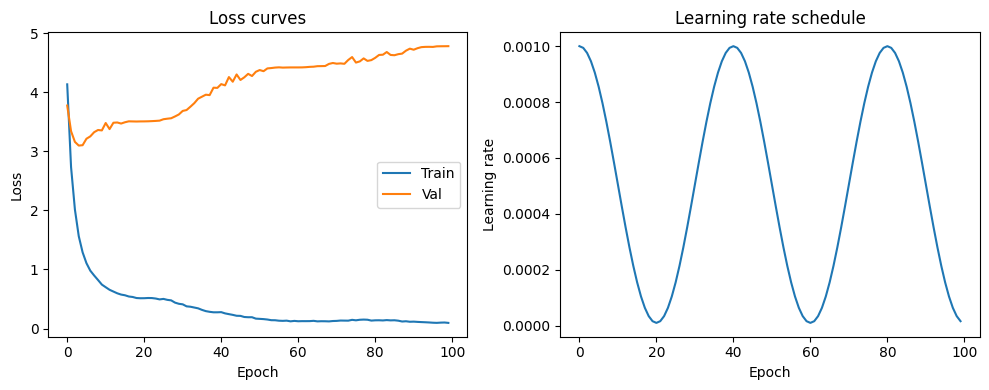

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history['lr'])
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Learning rate schedule')

plt.tight_layout()
plt.show()

In [ ]:
def generate(cnn, decoder, image, word2idx, idx2word, device, max_length=150):
    cnn.eval()
    decoder.eval()

    with torch.no_grad():
        # 1. prepare image — add batch dimension
        image = image.unsqueeze(0).to(device)  # [1, 3, 128, 128]

        # 2. get CNN features
        memory = cnn(image)  # [1, num_patches, 256]

        # 3. start with <START> token
        tokens = [word2idx['<START>']]

        # 4. generate tokens one at a time
        for _ in range(max_length):

            # convert current tokens to tensor
            tokens_tensor = torch.tensor(tokens).unsqueeze(0).to(device)  # [1, seq_len]

            # pass through decoder
            output = decoder(tokens_tensor, memory)  # [1, seq_len, vocab_size]

            # get predicted next token
            next_token = torch.argmax(output[0, -1, :]).item()

            # if <END> stop
            # otherwise add to tokens
            if next_token == word2idx['<END>']:
                break
            else:
                tokens.append(next_token)

    # 5. convert tokens back to words
    words = [idx2word[token] for token in tokens[1:]]

    # 6. return sentence
    # return generated sentence
    return ' '.join(words)


In [ ]:
# get a single image from training data
sample = small_dataset[0]
# idx = small_dataset.indices[0]  # get original index
image, sequence = sample

# generate sentence
generated = generate(cnn, decoder, image, word2idx, idx2word, device)
print(f"Generated: {generated}")

# compare to ground truth
ground_truth = balanced_dataset.iloc[0]['text']
print(f"Ground truth: {ground_truth}")

Generated: three numbers appear in the scene a small four hundred and thirty one , a large eight , and a large five hundred and thirty three . a large eight overlaps a large five hundred and thirty three .
Ground truth: in total, three numbers: a large ninety one, a medium six hundred and four, and a medium eight thousand two hundred and seventy nine. a large ninety one overlaps a medium six hundred and four.


In [ ]:
for i in [random.randint(0,99) for i in]:
    image, sequence = small_dataset[i]
    # idx = balanced_dataset.loc[i]
    ground_truth = balanced_dataset.iloc[i]['text']
    generated = generate(cnn, decoder, image, word2idx, idx2word, device)
    print(f"Sample {i}:")
    print(f"  Generated:    {generated}")
    print(f"  Ground truth: {ground_truth}")
    print()

Sample 48:
  Generated:    from top to bottom a medium yellow square , a large yellow circle , a large orange star , and a medium red triangle .
  Ground truth: four shapes populate the scene: a large blue triangle, a small cyan star, a large cyan square, and a small pink pentagon.

Sample 12:
  Generated:    the scene contains a large one thousand eight hundred and eighteen , a medium three hundred and forty three , a large ninety one , and a small twenty three .
  Ground truth: in total, four numbers: a medium seven thousand seven hundred and thirty nine, a large eight hundred and fifty eight, a small one, and a small nine. a medium seven thousand seven hundred and thirty nine overlaps a large eight hundred and fifty eight.

Sample 68:
  Generated:    player_x has taken middle row right , center , bottom left corner and middle row left . player_o has gone for bottom middle , bottom right corner and top right corner . player_x controls the center . player_x has won .
  Ground truth: p

In [ ]:
train_data[train_data['file_name']=='sample_003565.png']['file_path'].iloc[0]

'/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data/Numbers_Data/train/images/sample_003565.png'

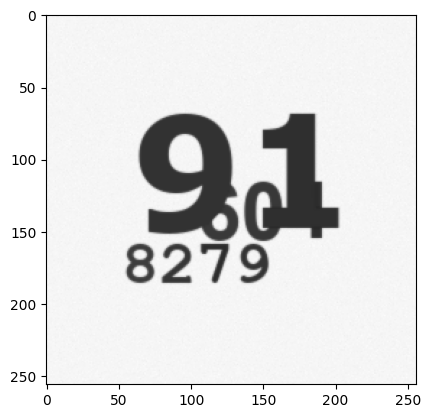

In [ ]:
img = cv2.imread('/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data/Numbers_Data/train/images/sample_003565.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [ ]:
indices = small_dataset.indices
small_subset = train_data.iloc[indices]
print(small_subset['dataset'].value_counts())

dataset
Numbers_Data    100
Name: count, dtype: int64


### Full model Training

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

### Shallow CNN

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cnn     = ShallowCNN().to(device)
decoder = TransformerDecoder(vocab_size=172).to(device)

optimizer = torch.optim.Adam(
    list(cnn.parameters()) + list(decoder.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-5
)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [ ]:
history_shallow = train(
    cnn, decoder, train_loader, val_loader,
    optimizer, criterion, device,
    num_epochs=50, patience=5
)

Epoch 1/50 | Train Loss: 1.5573 | Val Loss: 1.0187
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9792 | Val Loss: 0.8982
  Model saved ✅


Epoch 3/50 | Train Loss: 0.8927 | Val Loss: 0.8271
  Model saved ✅


Epoch 4/50 | Train Loss: 0.8259 | Val Loss: 0.7721
  Model saved ✅


Epoch 5/50 | Train Loss: 0.7791 | Val Loss: 0.7514
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7466 | Val Loss: 0.7161
  Model saved ✅


Epoch 7/50 | Train Loss: 0.7226 | Val Loss: 0.7002
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6989 | Val Loss: 0.6804
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6799 | Val Loss: 0.6689
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6609 | Val Loss: 0.6679
  Model saved ✅


Epoch 11/50 | Train Loss: 0.6433 | Val Loss: 0.6437
  Model saved ✅


Epoch 12/50 | Train Loss: 0.6266 | Val Loss: 0.6315
  Model saved ✅


Epoch 13/50 | Train Loss: 0.6105 | Val Loss: 0.6205
  Model saved ✅


Epoch 14/50 | Train Loss: 0.5952 | Val Loss: 0.6160
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5801 | Val Loss: 0.6159
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5689 | Val Loss: 0.6029
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5513 | Val Loss: 0.5966
  Model saved ✅


Epoch 18/50 | Train Loss: 0.5402 | Val Loss: 0.6055


Epoch 19/50 | Train Loss: 0.5273 | Val Loss: 0.6202


Epoch 20/50 | Train Loss: 0.5131 | Val Loss: 0.5961
  Model saved ✅


Epoch 21/50 | Train Loss: 0.5001 | Val Loss: 0.5978


Epoch 22/50 | Train Loss: 0.4864 | Val Loss: 0.6038


Epoch 23/50 | Train Loss: 0.4740 | Val Loss: 0.6045


Epoch 24/50 | Train Loss: 0.4619 | Val Loss: 0.6102


Epoch 25/50 | Train Loss: 0.4478 | Val Loss: 0.6099
Early stopping at epoch 25


In [ ]:
torch.save({
    'cnn': cnn.state_dict(),
    'decoder': decoder.state_dict(),
    'history': history_shallow
}, '/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/shallow_cnn_final.pt')

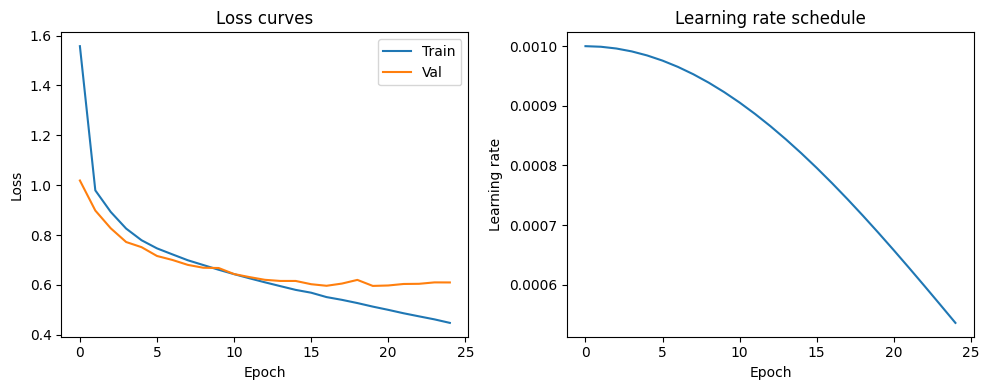

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_shallow['train_loss'], label='Train')
plt.plot(history_shallow['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_shallow['lr'])
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Learning rate schedule')

plt.tight_layout()
plt.show()

In [ ]:
test_data.shape

(2238, 9)

In [ ]:
for i in [random.randint(0, len(test_dataset)-1) for _ in range(10)]:
    image, sequence = test_dataset[i]
    ground_truth = test_data.iloc[i]['text']
    generated = generate(cnn, decoder, image, word2idx, idx2word, device)
    print(f"Sample {i}:")
    print(f"  Generated:    {generated}")
    print(f"  Ground truth: {ground_truth}")
    print()

Sample 1417:
  Generated:    player_x has gone for top right corner , middle row right , top left corner and bottom middle . player_o has taken bottom right corner , middle and left of centre . it is player_o s turn . player_o has two corners .
  Ground truth: player_x has gone for top middle, down and right from center, middle row left and up and right from center. player_o has taken up and left from center, middle, middle row right and bottom left corner. player_x is next to move. player_o controls the center.

Sample 850:
  Generated:    player_x has gone for middle row right . player_o has not moved yet . one move has been played .
  Ground truth: player_x has gone for middle. player_o has not moved yet. one move has been played. player_x controls the center.

Sample 551:
  Generated:    a small four hundred and twenty four at the top-centre . also a large fifty nine at the bottom-centre .
  Ground truth: in total, four numbers: a large two, a small six hundred and twelve, a small 

### DeepCNN & ResNet Training

In [ ]:
for model_name, CNNClass in [('deep', DeepCNN), ('resnet', ResNetCNN)]:
    print(f"\nTraining {model_name}...")
    cnn     = CNNClass().to(device)
    decoder = TransformerDecoder(vocab_size=172).to(device)
    optimizer = torch.optim.Adam(
        list(cnn.parameters()) + list(decoder.parameters()), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=50, eta_min=1e-5)
    history = train(cnn, decoder, train_loader, val_loader,
                    optimizer, criterion, device, num_epochs=50, patience=5,
                    save_path=f'/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/{model_name}_best.pt')
    torch.save({
        'cnn': cnn.state_dict(),
        'decoder': decoder.state_dict(),
        'history': history
    }, f'/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/{model_name}_cnn_final.pt')


Training deep...


Epoch 1/50 | Train Loss: 1.5632 | Val Loss: 1.0181
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9908 | Val Loss: 0.9087
  Model saved ✅


Epoch 3/50 | Train Loss: 0.9172 | Val Loss: 0.8495
  Model saved ✅


Epoch 4/50 | Train Loss: 0.8567 | Val Loss: 0.8115
  Model saved ✅


Epoch 5/50 | Train Loss: 0.8083 | Val Loss: 0.7665
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7719 | Val Loss: 0.7390
  Model saved ✅


Epoch 7/50 | Train Loss: 0.7454 | Val Loss: 0.7179
  Model saved ✅


Epoch 8/50 | Train Loss: 0.7226 | Val Loss: 0.7019
  Model saved ✅


Epoch 9/50 | Train Loss: 0.7013 | Val Loss: 0.6832
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6822 | Val Loss: 0.6713
  Model saved ✅


Epoch 11/50 | Train Loss: 0.6630 | Val Loss: 0.6609
  Model saved ✅


Epoch 12/50 | Train Loss: 0.6427 | Val Loss: 0.6293
  Model saved ✅


Epoch 13/50 | Train Loss: 0.6229 | Val Loss: 0.6197
  Model saved ✅


Epoch 14/50 | Train Loss: 0.6055 | Val Loss: 0.6143
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5886 | Val Loss: 0.5968
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5703 | Val Loss: 0.5947
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5482 | Val Loss: 0.5660
  Model saved ✅


Epoch 18/50 | Train Loss: 0.5236 | Val Loss: 0.5585
  Model saved ✅


Epoch 19/50 | Train Loss: 0.5050 | Val Loss: 0.5331
  Model saved ✅


Epoch 20/50 | Train Loss: 0.4814 | Val Loss: 0.5256
  Model saved ✅


Epoch 21/50 | Train Loss: 0.4608 | Val Loss: 0.5175
  Model saved ✅


Epoch 22/50 | Train Loss: 0.4412 | Val Loss: 0.5026
  Model saved ✅


Epoch 23/50 | Train Loss: 0.4220 | Val Loss: 0.5000
  Model saved ✅


Epoch 24/50 | Train Loss: 0.4033 | Val Loss: 0.4999
  Model saved ✅


Epoch 25/50 | Train Loss: 0.3850 | Val Loss: 0.4952
  Model saved ✅


Epoch 26/50 | Train Loss: 0.3669 | Val Loss: 0.4986


Epoch 27/50 | Train Loss: 0.3514 | Val Loss: 0.4942
  Model saved ✅


Epoch 28/50 | Train Loss: 0.3364 | Val Loss: 0.5034


Epoch 29/50 | Train Loss: 0.3217 | Val Loss: 0.5045


Epoch 30/50 | Train Loss: 0.3072 | Val Loss: 0.5079


Epoch 31/50 | Train Loss: 0.2940 | Val Loss: 0.5115


Epoch 32/50 | Train Loss: 0.2804 | Val Loss: 0.5201
Early stopping at epoch 32

Training resnet...


Epoch 1/50 | Train Loss: 1.5685 | Val Loss: 1.0164
  Model saved ✅


Epoch 2/50 | Train Loss: 0.9845 | Val Loss: 0.8965
  Model saved ✅


Epoch 3/50 | Train Loss: 0.8909 | Val Loss: 0.8140
  Model saved ✅


Epoch 4/50 | Train Loss: 0.8174 | Val Loss: 0.7829
  Model saved ✅


Epoch 5/50 | Train Loss: 0.7778 | Val Loss: 0.7424
  Model saved ✅


Epoch 6/50 | Train Loss: 0.7437 | Val Loss: 0.7189
  Model saved ✅


Epoch 7/50 | Train Loss: 0.7142 | Val Loss: 0.6828
  Model saved ✅


Epoch 8/50 | Train Loss: 0.6886 | Val Loss: 0.6668
  Model saved ✅


Epoch 9/50 | Train Loss: 0.6669 | Val Loss: 0.6553
  Model saved ✅


Epoch 10/50 | Train Loss: 0.6475 | Val Loss: 0.6390
  Model saved ✅


Epoch 11/50 | Train Loss: 0.6263 | Val Loss: 0.6333
  Model saved ✅


Epoch 12/50 | Train Loss: 0.6057 | Val Loss: 0.6172
  Model saved ✅


Epoch 13/50 | Train Loss: 0.5855 | Val Loss: 0.5941
  Model saved ✅


Epoch 14/50 | Train Loss: 0.5710 | Val Loss: 0.5801
  Model saved ✅


Epoch 15/50 | Train Loss: 0.5551 | Val Loss: 0.5768
  Model saved ✅


Epoch 16/50 | Train Loss: 0.5387 | Val Loss: 0.5660
  Model saved ✅


Epoch 17/50 | Train Loss: 0.5224 | Val Loss: 0.5671


Epoch 18/50 | Train Loss: 0.5079 | Val Loss: 0.5700


Epoch 19/50 | Train Loss: 0.4961 | Val Loss: 0.5607
  Model saved ✅


Epoch 20/50 | Train Loss: 0.4855 | Val Loss: 0.5695


Epoch 21/50 | Train Loss: 0.4685 | Val Loss: 0.5569
  Model saved ✅


Epoch 22/50 | Train Loss: 0.4558 | Val Loss: 0.5531
  Model saved ✅


Epoch 23/50 | Train Loss: 0.4412 | Val Loss: 0.5639


Epoch 24/50 | Train Loss: 0.4299 | Val Loss: 0.5708


Epoch 25/50 | Train Loss: 0.4161 | Val Loss: 0.5679


Epoch 26/50 | Train Loss: 0.4008 | Val Loss: 0.5667


Epoch 27/50 | Train Loss: 0.3886 | Val Loss: 0.5750
Early stopping at epoch 27


### Have to try

In [ ]:
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',        # reduce when metric stops decreasing
#     factor=0.5,        # multiply lr by 0.5 when triggered
#     patience=3,        # wait 3 epochs before reducing
#     min_lr=1e-6        # never go below this
# )



# Change in the train function

# old - no argument needed
# scheduler.step()

# new - pass val loss
# scheduler.step(val_loss)




# for model_name, CNNClass in [('shallow', ShallowCNN), ('deep', DeepCNN), ('resnet', ResNetCNN)]:
#     print(f"\nTraining {model_name}...")
#     cnn     = CNNClass().to(device)
#     decoder = TransformerDecoder(vocab_size=172).to(device)
#     optimizer = torch.optim.Adam(
#         list(cnn.parameters()) + list(decoder.parameters()), lr=1e-3)
#     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#         optimizer, T_max=50, eta_min=1e-5)

#     # pass model name to train function so it saves correctly
#     history = train(cnn, decoder, train_loader, val_loader,
#                     optimizer, criterion, device,
#                     num_epochs=50, patience=5,
#                     save_path=f'/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Model_Results/{model_name}_cnn_final.pt')

# Rough

In [ ]:
words = []
for text in master_data['text']:
  words.extend(text.split(" "))

In [ ]:
pd.Series(words).nunique()

323

In [ ]:
pd.Series(words).value_counts()[:100]

,count
and,32182
a,31627
in,18792
the,17937
has,12315
small,11801
large,11695
medium,9363
left,8197
player_x,7937


In [ ]:
for text in master_data['text']:
  if '-' in text:
    print(text)

a small five thousand two hundred and fifty three, with five in orange, two in yellow, five in green and three in purple at the middle-left and a large orange nine at the middle-right appear in the scene.
two numbers are visible: a small two hundred and twenty three, with two in purple, two in blue and three in purple at the middle-left and a large six thousand five hundred and thirty, with six in green, five in red, three in pink and zero in cyan at the top-centre.
a large one hundred and fifty two, with one in red, five in blue and two in pink at the top-centre and a medium four hundred and four, with four in purple, zero in yellow and four in orange at the middle-left appear in the scene.
a large four hundred and sixty two, with four in green, six in blue and two in red at the middle of the image. also a large thirty seven, with three in purple and seven in orange at the top-centre.
a medium four hundred and eighty three, with four in green, eight in yellow and three in purple at th

In [ ]:
num2words(15)

'fifteen'

In [ ]:
count = []
for text in master_data['text']:
  count.append(len(text.split(" ")))

max(count)

140

In [ ]:
pd.Series(count).describe()

,0
count,15000.000000
mean,29.186600
std,16.489739
min,2.000000
25%,18.000000
50%,26.000000
75%,36.000000
max,140.000000


In [ ]:
master_data['word_count'] = master_data['text'].apply(lambda x: len(x.split()))

In [ ]:
master_data[master_data['word_count']==140]

,file_name,file_path,text,split,dataset,word_count
476,sample_004229.png,/content/drive/Othercomputers/My Laptop/Deskto...,"in total, four numbers: a medium six thousand ...",train,Numbers_Data,140
528,sample_004280.png,/content/drive/Othercomputers/My Laptop/Deskto...,four numbers appear in the scene: a large seve...,train,Numbers_Data,140


In [ ]:
master_data[master_data['file_name']=='sample_004229.png'].iloc[0]['text']

'in total, four numbers: a medium six thousand one hundred and sixteen, with six in pink, one in orange, one in orange and six in yellow, a medium five thousand and eighty seven, with five in yellow, zero in pink, eight in red and seven in pink, a large seven thousand one hundred and forty nine, with seven in yellow, one in blue, four in red and nine in yellow, and a large eight thousand six hundred and eighty seven, with eight in cyan, six in green, eight in purple and seven in purple. a medium six thousand one hundred and sixteen, with six in pink, one in orange, one in orange and six in yellow overlaps a large eight thousand six hundred and eighty seven, with eight in cyan, six in green, eight in purple and seven in purple.'

In [ ]:
temp_df = raw_data['Numbers_Data']

In [ ]:
temp_df[temp_df['file_name']=='sample_004229.png'].iloc[0]['text']

'In total, four numbers: a mid-sized 6116, with 6 in pink, 1 in orange, 1 in orange and 6 in yellow, a medium 5087, with 5 in yellow, 0 in pink, 8 in red and 7 in pink, a large 7149, with 7 in yellow, 1 in blue, 4 in red and 9 in yellow, and a big 8687, with 8 in cyan, 6 in green, 8 in purple and 7 in purple. A medium 6116, with 6 in pink, 1 in orange, 1 in orange and 6 in yellow overlaps a large 8687, with 8 in cyan, 6 in green, 8 in purple and 7 in purple.\n'

In [ ]:
master_data[master_data['word_count'] > 50].groupby('dataset').size()

,0
dataset,
Numbers_Data,989
TicTacToe_Data,4


In [ ]:
numbers_data = master_data[master_data['dataset'] == 'Numbers_Data']
numbers_data['word_count'].describe()

,word_count
count,5000.000000
mean,34.656800
std,24.212696
min,2.000000
25%,19.000000
50%,28.000000
75%,45.000000
max,140.000000


In [ ]:
percentiles = [50, 75, 90, 95, 99, 100]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(numbers_data['word_count'], p):.0f}")

50th percentile: 28
75th percentile: 45
90th percentile: 70
95th percentile: 87
99th percentile: 111
100th percentile: 140


### Running all three models

In [ ]:
models = {
    'ShallowCNN': ShallowCNN(),
    'DeepCNN':    DeepCNN(),
    'ResNetCNN':  ResNetCNN()
}

results = {}
for name, cnn in models.items():
    print(f"\nTraining {name}...")
    cnn = cnn.to(device)
    decoder = TransformerDecoder(vocab_size=172).to(device)
    optimizer = torch.optim.Adam(
        list(cnn.parameters()) + list(decoder.parameters()), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)
    results[name] = train(cnn, decoder, train_loader, val_loader, optimizer, criterion, device)